In [26]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import ipywidgets as widgets

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from IPython.display import display, HTML
from google.colab import output
output.enable_custom_widget_manager()

**Data Understanding**

In [27]:
# =========================
# 2. DATA UNDERSTANDING
# =========================
df_main = pd.read_csv("Student_performance_data _.csv")
df_resp = pd.read_csv("responden.csv")

print("\n===== INFO DATA =====")
df_main.info()

print("\n===== STATISTIK DESKRIPTIF =====")
print(df_main.describe())


===== INFO DATA =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2392 non-null   int64  
 3   Ethnicity          2392 non-null   int64  
 4   ParentalEducation  2392 non-null   int64  
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   ParentalSupport    2392 non-null   int64  
 9   Extracurricular    2392 non-null   int64  
 10  Sports             2392 non-null   int64  
 11  Music              2392 non-null   int64  
 12  Volunteering       2392 non-null   int64  
 13  GPA                2392 non-null   float64
 14  GradeClass         2392 non-null   float64
dtypes: float64(3), int64(12)
memory usage: 280.4 KB



**Data** **Preprocessing**


Missing Value:
ParentalSupport      0
Extracurricular      0
GPA                  0
Tutoring             0
Absences             0
Gender               0
GradeClass           0
ParentalEducation    0
StudyTimeWeekly      0
dtype: int64

Duplikat: 2

Jumlah Outlier: 60


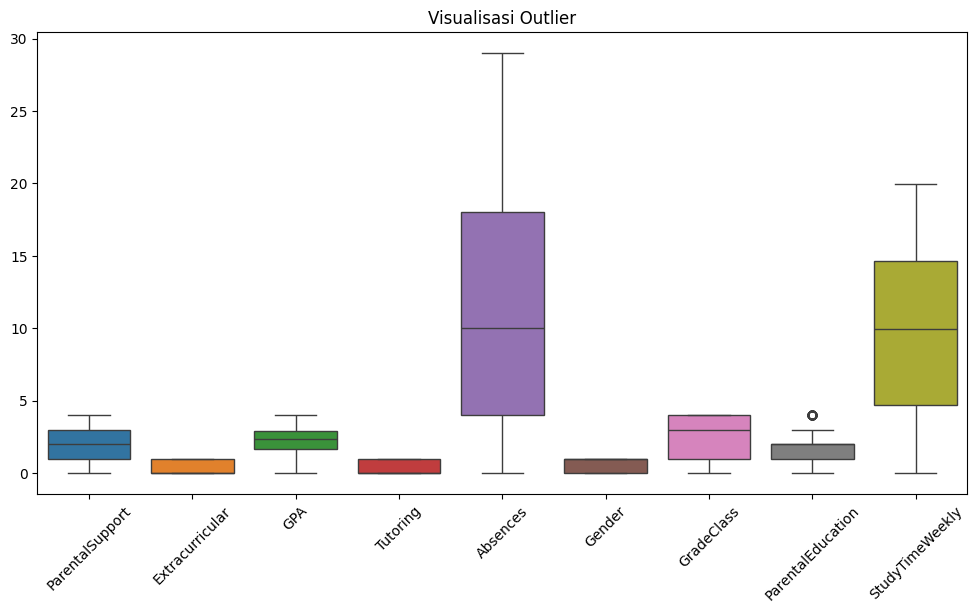

In [28]:
df_main = df_main.drop(columns=["StudentID"], errors='ignore')

le = LabelEncoder()
for col in df_resp.columns:
    if df_resp[col].dtype == 'object':
        df_resp[col] = le.fit_transform(df_resp[col].astype(str))

common_cols = list(set(df_main.columns).intersection(set(df_resp.columns)))
if "GradeClass" not in common_cols:
    common_cols.append("GradeClass")

df_main = df_main[common_cols]
df_resp = df_resp[common_cols]

df = pd.concat([df_main, df_resp], ignore_index=True)

print("\nMissing Value:")
print(df.isnull().sum())
df = df.dropna()

print("\nDuplikat:", df.duplicated().sum())
df = df.drop_duplicates()

# 5. BALANCING
target_dict = {
    0: 130,
    1: 260  ,
    2: 330,
    3: 330,
    4: 420
}

df_balanced = pd.DataFrame()

for kelas, target_n in target_dict.items():
    df_kelas = df[df['GradeClass'] == kelas]

    if len(df_kelas) > target_n:
        df_kelas = df_kelas.sample(target_n, random_state=42)

    df_balanced = pd.concat([df_balanced, df_kelas])

df = df_balanced.reset_index(drop=True)

# 6. OUTLIER

Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

# Deteksi outlier
outliers = df[((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]
print("\nJumlah Outlier:", len(outliers))

# Visualisasi
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.title("Visualisasi Outlier")
plt.xticks(rotation=45)
plt.show()

# Hapus outlier
df = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

df = df.sample(frac=1, random_state=42).reset_index(drop=True)

**Exploratory Data Analysis (EDA)**

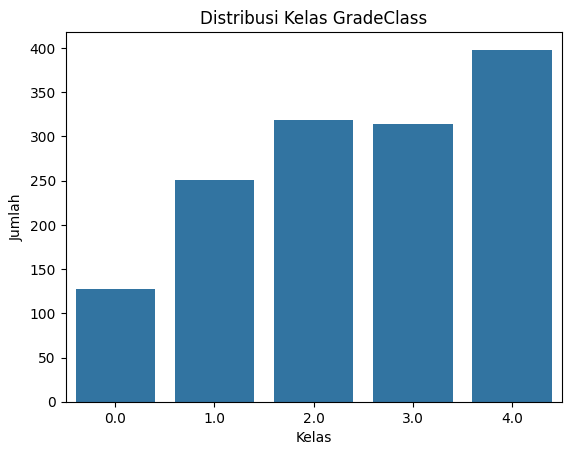

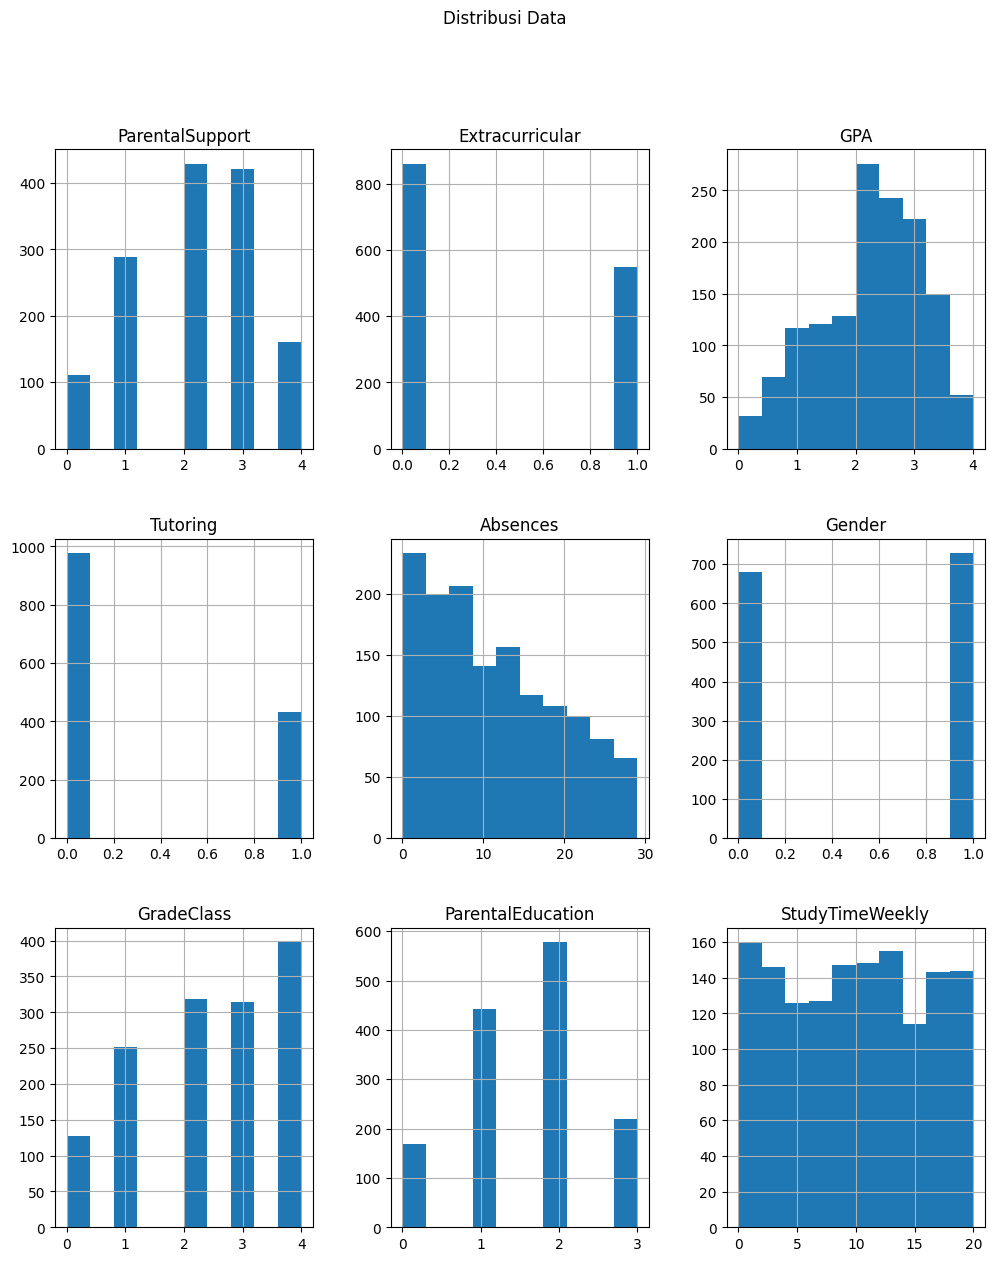

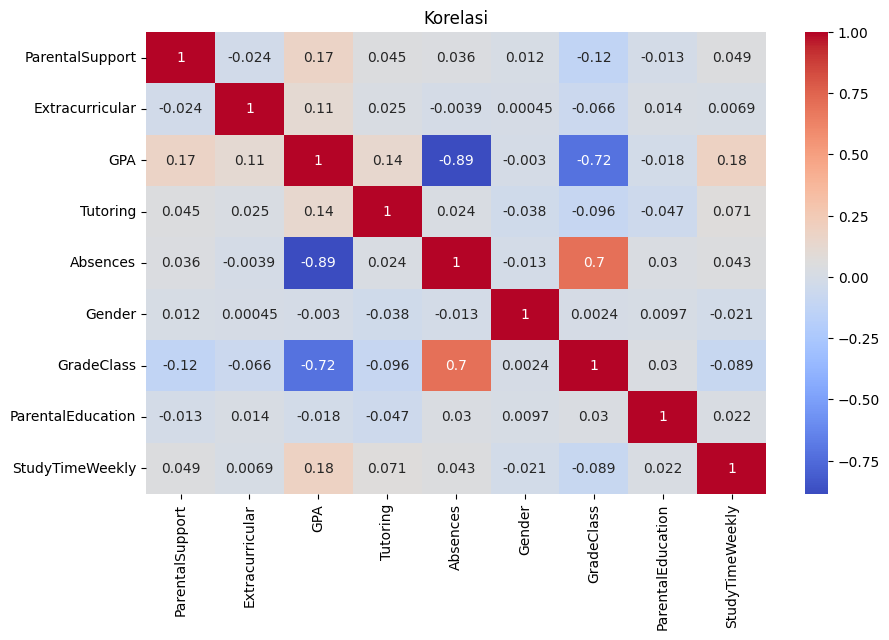


Statistik Deskriptif Setelah Cleaning:
       ParentalSupport  Extracurricular          GPA     Tutoring  \
count      1410.000000      1410.000000  1410.000000  1410.000000   
mean          2.163121         0.389362     2.250352     0.306383   
std           1.116520         0.487779     0.887083     0.461154   
min           0.000000         0.000000     0.000000     0.000000   
25%           1.000000         0.000000     1.635866     0.000000   
50%           2.000000         0.000000     2.333749     0.000000   
75%           3.000000         1.000000     2.917857     1.000000   
max           4.000000         1.000000     4.000000     1.000000   

          Absences       Gender   GradeClass  ParentalEducation  \
count  1410.000000  1410.000000  1410.000000        1410.000000   
mean     11.264539     0.517021     2.427660           1.602128   
std       8.226406     0.499887     1.308139           0.889890   
min       0.000000     0.000000     0.000000           0.000000   
25%

In [29]:
plt.figure()
sns.countplot(x=df['GradeClass'])
plt.title("Distribusi Kelas GradeClass")
plt.xlabel("Kelas")
plt.ylabel("Jumlah")
plt.show()

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

df[num_cols].hist(figsize=(12,14))

plt.suptitle("Distribusi Data")
plt.show()

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Korelasi")
plt.show()

print("\nStatistik Deskriptif Setelah Cleaning:")
print(df.describe())

**Featur & Target |  Standarisasi**

In [30]:
X = df.drop("GradeClass", axis=1)
y = df["GradeClass"]

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [31]:
#DATA SPLITTING
splits = {
    "70:30": 0.3,
    "80:20": 0.2,
    "90:10": 0.1
}

**Model Building**

In [32]:
models = {

    "AdaBoost": GridSearchCV(
        AdaBoostClassifier(),
        {
            'n_estimators': [120, 150],
            'learning_rate': [0.5, 0.7]
        },
        cv=3,
        n_jobs=-1
    ),

    "Gradient Boosting": GridSearchCV(
        GradientBoostingClassifier(random_state=42),
        {
            'n_estimators': [150, 180],
            'learning_rate': [0.06, 0.08],
            'max_depth': [3],
            'subsample': [0.9]
        },
        cv=3,
        n_jobs=-1
    ),

    "XGBoost": GridSearchCV(
        XGBClassifier(
            use_label_encoder=False,
            eval_metric='mlogloss',
            verbosity=0
        ),
        {
            'n_estimators': [180, 200],
            'learning_rate': [0.05, 0.08],
            'max_depth': [3, 4],
            'subsample': [0.8],
            'colsample_bytree': [0.8]
        },
        cv=3,
        n_jobs=-1
    )
}


**Hyperparameter** **Tuning**


MODEL: AdaBoost

--- Split: 70:30 ---
Best Param: {'learning_rate': 0.5, 'n_estimators': 120}
Accuracy: 0.9054373522458629
              precision    recall  f1-score   support

         0.0       0.87      0.69      0.77        39
         1.0       0.95      0.83      0.89        75
         2.0       0.94      0.93      0.93        96
         3.0       0.92      0.93      0.92        94
         4.0       0.86      0.99      0.92       119

    accuracy                           0.91       423
   macro avg       0.91      0.87      0.89       423
weighted avg       0.91      0.91      0.90       423

[[ 27   0   4   2   6]
 [  3  62   0   4   6]
 [  1   1  89   1   4]
 [  0   2   2  87   3]
 [  0   0   0   1 118]]


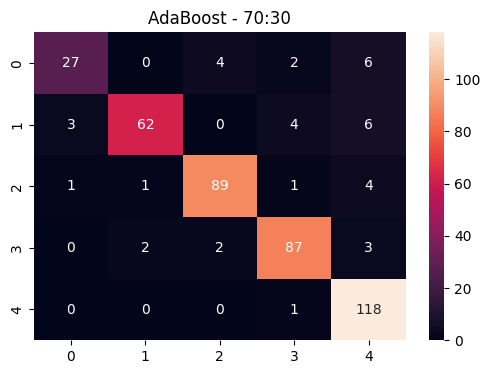


--- Split: 80:20 ---
Best Param: {'learning_rate': 0.5, 'n_estimators': 150}
Accuracy: 0.9219858156028369
              precision    recall  f1-score   support

         0.0       0.95      0.77      0.85        26
         1.0       0.96      0.88      0.92        50
         2.0       0.94      0.91      0.92        64
         3.0       0.94      0.94      0.94        63
         4.0       0.88      1.00      0.93        79

    accuracy                           0.92       282
   macro avg       0.93      0.90      0.91       282
weighted avg       0.92      0.92      0.92       282

[[20  0  3  0  3]
 [ 0 44  0  3  3]
 [ 1  1 58  1  3]
 [ 0  1  1 59  2]
 [ 0  0  0  0 79]]


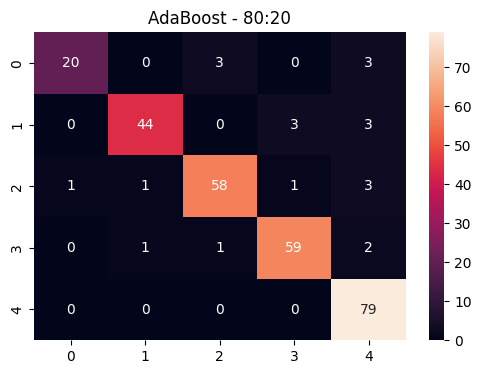


--- Split: 90:10 ---
Best Param: {'learning_rate': 0.5, 'n_estimators': 120}
Accuracy: 0.9290780141843972
              precision    recall  f1-score   support

         0.0       1.00      0.69      0.82        13
         1.0       0.96      0.88      0.92        25
         2.0       0.94      0.94      0.94        32
         3.0       0.94      0.97      0.95        31
         4.0       0.89      1.00      0.94        40

    accuracy                           0.93       141
   macro avg       0.94      0.90      0.91       141
weighted avg       0.93      0.93      0.93       141

[[ 9  0  2  0  2]
 [ 0 22  0  1  2]
 [ 0  0 30  1  1]
 [ 0  1  0 30  0]
 [ 0  0  0  0 40]]


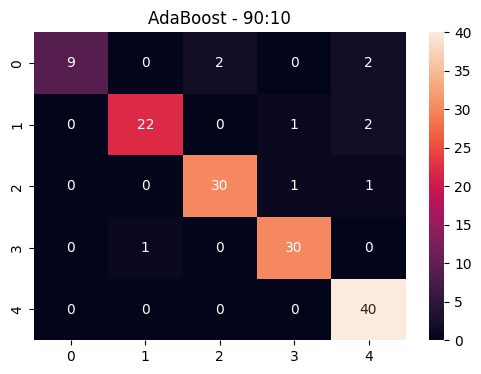


MODEL: Gradient Boosting

--- Split: 70:30 ---
Best Param: {'learning_rate': 0.06, 'max_depth': 3, 'n_estimators': 150, 'subsample': 0.9}
Accuracy: 0.8959810874704491
              precision    recall  f1-score   support

         0.0       0.87      0.67      0.75        39
         1.0       0.91      0.84      0.88        75
         2.0       0.94      0.92      0.93        96
         3.0       0.90      0.93      0.91        94
         4.0       0.86      0.97      0.91       119

    accuracy                           0.90       423
   macro avg       0.90      0.86      0.88       423
weighted avg       0.90      0.90      0.89       423

[[ 26   2   4   2   5]
 [  2  63   0   4   6]
 [  2   1  88   1   4]
 [  0   2   2  87   3]
 [  0   1   0   3 115]]


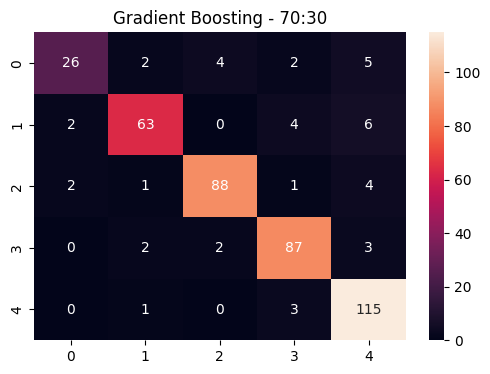


--- Split: 80:20 ---
Best Param: {'learning_rate': 0.06, 'max_depth': 3, 'n_estimators': 150, 'subsample': 0.9}
Accuracy: 0.9113475177304965
              precision    recall  f1-score   support

         0.0       0.90      0.73      0.81        26
         1.0       0.94      0.88      0.91        50
         2.0       0.93      0.89      0.91        64
         3.0       0.92      0.94      0.93        63
         4.0       0.88      0.99      0.93        79

    accuracy                           0.91       282
   macro avg       0.91      0.89      0.90       282
weighted avg       0.91      0.91      0.91       282

[[19  1  3  0  3]
 [ 0 44  0  3  3]
 [ 2  1 57  1  3]
 [ 0  1  1 59  2]
 [ 0  0  0  1 78]]


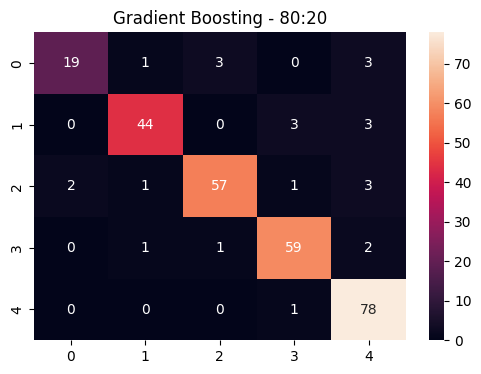


--- Split: 90:10 ---
Best Param: {'learning_rate': 0.06, 'max_depth': 3, 'n_estimators': 150, 'subsample': 0.9}
Accuracy: 0.9219858156028369
              precision    recall  f1-score   support

         0.0       0.90      0.69      0.78        13
         1.0       0.96      0.88      0.92        25
         2.0       0.94      0.91      0.92        32
         3.0       0.94      0.97      0.95        31
         4.0       0.89      1.00      0.94        40

    accuracy                           0.92       141
   macro avg       0.92      0.89      0.90       141
weighted avg       0.92      0.92      0.92       141

[[ 9  0  2  0  2]
 [ 0 22  0  1  2]
 [ 1  0 29  1  1]
 [ 0  1  0 30  0]
 [ 0  0  0  0 40]]


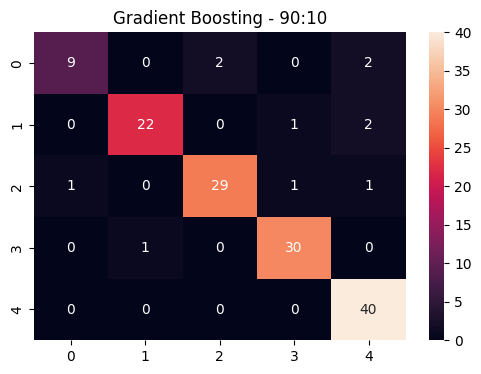


MODEL: XGBoost

--- Split: 70:30 ---
Best Param: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 180, 'subsample': 0.8}
Accuracy: 0.9030732860520094
              precision    recall  f1-score   support

         0.0       0.88      0.72      0.79        39
         1.0       0.94      0.83      0.88        75
         2.0       0.93      0.92      0.92        96
         3.0       0.92      0.91      0.92        94
         4.0       0.86      0.99      0.92       119

    accuracy                           0.90       423
   macro avg       0.91      0.87      0.89       423
weighted avg       0.91      0.90      0.90       423

[[ 28   0   4   1   6]
 [  3  62   0   4   6]
 [  1   2  88   1   4]
 [  0   2   3  86   3]
 [  0   0   0   1 118]]


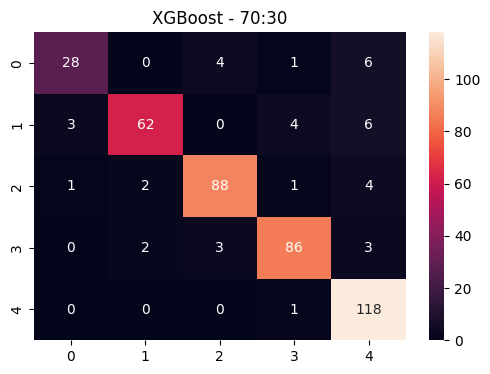


--- Split: 80:20 ---
Best Param: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 180, 'subsample': 0.8}
Accuracy: 0.9184397163120568
              precision    recall  f1-score   support

         0.0       0.95      0.77      0.85        26
         1.0       0.96      0.88      0.92        50
         2.0       0.93      0.89      0.91        64
         3.0       0.92      0.94      0.93        63
         4.0       0.88      1.00      0.93        79

    accuracy                           0.92       282
   macro avg       0.93      0.90      0.91       282
weighted avg       0.92      0.92      0.92       282

[[20  0  3  0  3]
 [ 0 44  0  3  3]
 [ 1  1 57  2  3]
 [ 0  1  1 59  2]
 [ 0  0  0  0 79]]


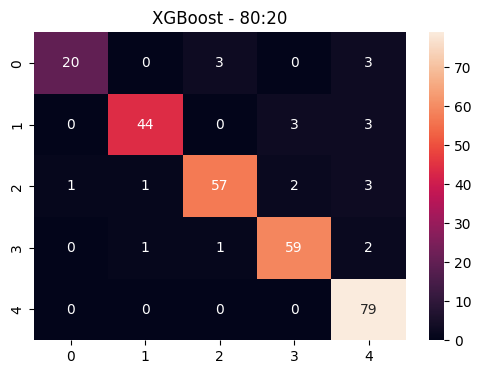


--- Split: 90:10 ---
Best Param: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 180, 'subsample': 0.8}
Accuracy: 0.9290780141843972
              precision    recall  f1-score   support

         0.0       1.00      0.69      0.82        13
         1.0       0.96      0.88      0.92        25
         2.0       0.94      0.94      0.94        32
         3.0       0.94      0.97      0.95        31
         4.0       0.89      1.00      0.94        40

    accuracy                           0.93       141
   macro avg       0.94      0.90      0.91       141
weighted avg       0.93      0.93      0.93       141

[[ 9  0  2  0  2]
 [ 0 22  0  1  2]
 [ 0  0 30  1  1]
 [ 0  1  0 30  0]
 [ 0  0  0  0 40]]


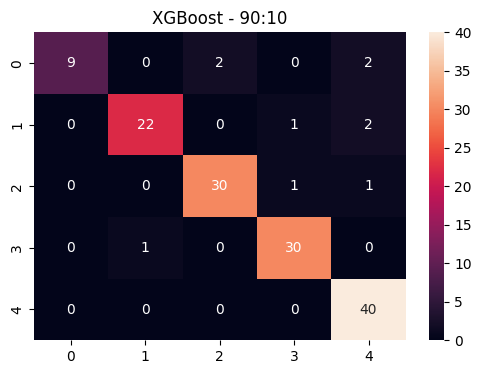

In [33]:
results = []

for model_name, model in models.items():

    print("\n==============================")
    print("MODEL:", model_name)
    print("==============================")

    for split_name, size in splits.items():

        print("\n--- Split:", split_name, "---")

        X_train, X_test, y_train, y_test = train_test_split(
            X, y,
            test_size=size,
            random_state=7,
            stratify=y
        )

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)

        print("Best Param:", model.best_params_)
        print("Accuracy:", acc)
        print(classification_report(y_test, y_pred))

        cm = confusion_matrix(y_test, y_pred)
        print(cm)

        plt.figure(figsize=(6,4))
        sns.heatmap(cm, annot=True, fmt='d')
        plt.title(f'{model_name} - {split_name}')
        plt.show()

        results.append([model_name, split_name, acc])

**Model** **Evaluation**

In [34]:
result_df = pd.DataFrame(results, columns=["Model", "Split", "Accuracy"])

print("\n===== HASIL EVALUASI MODEL =====")
print(result_df.sort_values(by="Accuracy", ascending=False))


===== HASIL EVALUASI MODEL =====
               Model  Split  Accuracy
2           AdaBoost  90:10  0.929078
8            XGBoost  90:10  0.929078
5  Gradient Boosting  90:10  0.921986
1           AdaBoost  80:20  0.921986
7            XGBoost  80:20  0.918440
4  Gradient Boosting  80:20  0.911348
0           AdaBoost  70:30  0.905437
6            XGBoost  70:30  0.903073
3  Gradient Boosting  70:30  0.895981


**Model Comparison**


===== PERFORMA TIAP MODEL =====
               Model  Accuracy
0           AdaBoost  0.918834
2            XGBoost  0.916864
1  Gradient Boosting  0.909771

===== PERFORMA TIAP SPLIT =====
   Split  Accuracy
2  90:10  0.926714
1  80:20  0.917258
0  70:30  0.901497


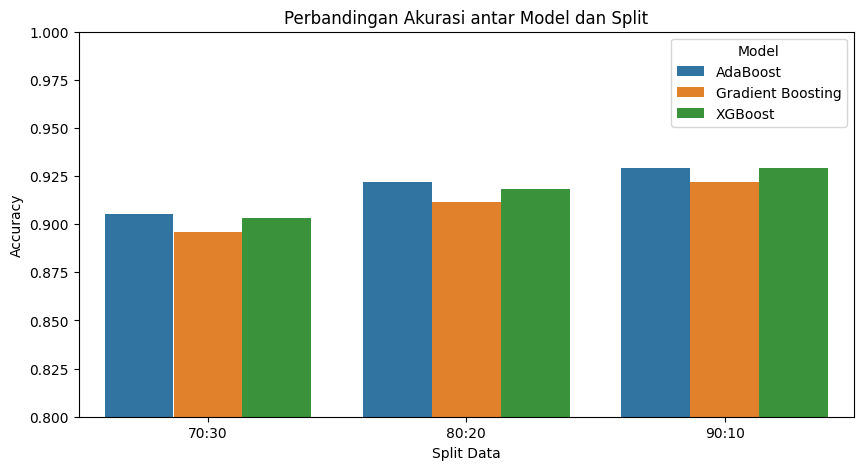

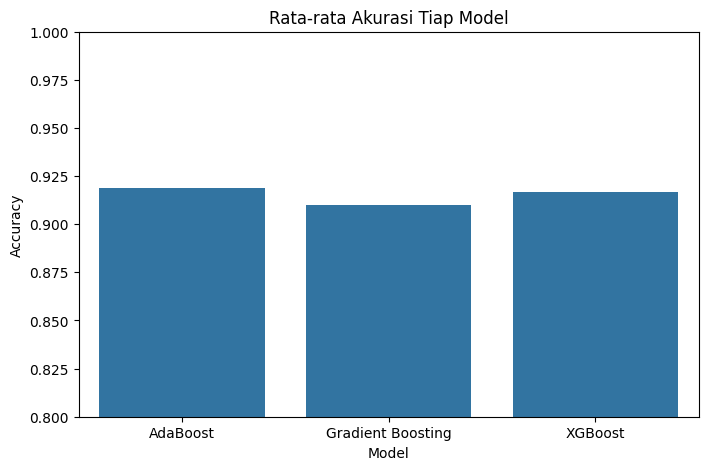

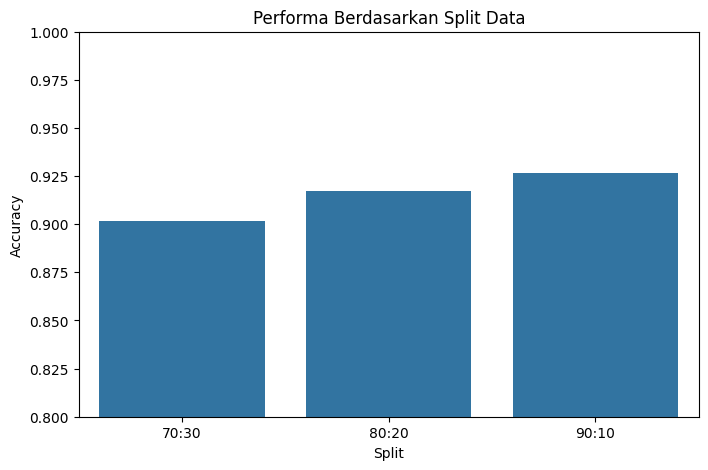

In [35]:
avg_model = result_df.groupby("Model")["Accuracy"].mean().reset_index()
print("\n===== PERFORMA TIAP MODEL =====")
print(avg_model.sort_values(by="Accuracy", ascending=False))

avg_split = result_df.groupby("Split")["Accuracy"].mean().reset_index()
print("\n===== PERFORMA TIAP SPLIT =====")
print(avg_split.sort_values(by="Accuracy", ascending=False))
plt.figure(figsize=(10, 5))
sns.barplot(x='Split', y='Accuracy', hue='Model', data=result_df)

plt.title('Perbandingan Akurasi antar Model dan Split')
plt.xlabel('Split Data')
plt.ylabel('Accuracy')
plt.ylim(0.8, 1.0)
plt.legend(title='Model')
plt.show()

avg_model = result_df.groupby("Model")["Accuracy"].mean().reset_index()
plt.figure(figsize=(8,5))
sns.barplot(x='Model', y='Accuracy', data=avg_model)
plt.title('Rata-rata Akurasi Tiap Model')
plt.ylabel('Accuracy')
plt.ylim(0.8, 1.0)
plt.show()

avg_split = result_df.groupby("Split")["Accuracy"].mean().reset_index()
plt.figure(figsize=(8,5))
sns.barplot(x='Split', y='Accuracy', data=avg_split)
plt.title('Performa Berdasarkan Split Data')
plt.ylabel('Accuracy')
plt.ylim(0.8, 1.0)
plt.show()

**Model untuk Deploy ke Streamlit**

In [36]:
import joblib

# Get the best estimators from GridSearchCV results
best_ada_model = models["AdaBoost"].best_estimator_
best_gb_model = models["Gradient Boosting"].best_estimator_
best_xgb_model = models["XGBoost"].best_estimator_

# Save the scaler and the best models
joblib.dump(scaler, 'scaler.joblib')
joblib.dump(best_ada_model, 'ada_boost_model.joblib')
joblib.dump(best_gb_model, 'gradient_boosting_model.joblib')
joblib.dump(best_xgb_model, 'xgb_model.joblib')

print("Scaler and best models saved successfully!")

Scaler and best models saved successfully!


In [37]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 43.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 40.5 MB/s eta 0:00:00


In [38]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib

# Load the scaler and models
scaler = joblib.load('scaler.joblib')
ada_boost_model = joblib.load('ada_boost_model.joblib')
gradient_boosting_model = joblib.load('gradient_boosting_model.joblib')
xgb_model = joblib.load('xgb_model.joblib')

# Feature names (ensure these match the training order)
feature_names = ['ParentalSupport', 'Extracurricular', 'GPA', 'Tutoring', 'Absences', 'Gender', 'ParentalEducation', 'StudyTimeWeekly']

# GradeClass mapping
label_map = {
    0: "Sangat Rendah",
    1: "Rendah",
    2: "Sedang",
    3: "Baik",
    4: "Sangat Baik"
}

st.set_page_config(page_title="Student Academic Performance Predictor", layout="wide")
st.title("🎓 Prediksi Performa Akademik Mahasiswa")

st.write("### Masukkan Data Mahasiswa untuk Prediksi")

# Create a sidebar for model selection
st.sidebar.header("Pilih Model")
selected_model_name = st.sidebar.selectbox(
    "Pilih Algoritma Model:",
    ("AdaBoost", "Gradient Boosting", "XGBoost")
)

models = {
    "AdaBoost": ada_boost_model,
    "Gradient Boosting": gradient_boosting_model,
    "XGBoost": xgb_model
}

selected_model = models[selected_model_name]

# Input fields for features
with st.form("prediction_form"):
    col1, col2, col3 = st.columns(3)

    with col1:
        parental_support = st.slider('Dukungan Orang Tua (0=Tidak ada, 4=Sangat Tinggi)', 0, 4, 2)
        extracurricular = st.radio('Kegiatan Ekstrakurikuler (0=Tidak, 1=Ya)', (0, 1))
        gpa = st.number_input('IPK (0.0 - 4.0)', min_value=0.0, max_value=4.0, value=2.5, step=0.01)

    with col2:
        tutoring = st.radio('Bimbingan Belajar (0=Tidak, 1=Ya)', (0, 1))
        absences = st.slider('Jumlah Ketidakhadiran', 0, 30, 10)
        gender = st.radio('Jenis Kelamin (0=Perempuan, 1=Laki-laki)', (0, 1))

    with col3:
        parental_education = st.slider('Pendidikan Orang Tua (0=Tidak ada, 3=Tinggi)', 0, 3, 1)
        study_time_weekly = st.number_input('Waktu Belajar Mingguan (jam)', min_value=0.0, max_value=20.0, value=10.0, step=0.1)

    submit_button = st.form_submit_button("Prediksi")

if submit_button:
    # Create a DataFrame from inputs
    input_data = pd.DataFrame([[parental_support, extracurricular, gpa, tutoring, absences, gender, parental_education, study_time_weekly]], columns=feature_names)

    # Scale the input data
    scaled_input_data = scaler.transform(input_data)

    # Make prediction
    prediction = selected_model.predict(scaled_input_data)[0]

    st.subheader("Hasil Prediksi:")
    st.success(f"GradeClass yang Diprediksi: **{int(prediction)}**")
    st.info(f"Interpretasi: **{label_map[prediction]}**")

st.write("---_Note: The 'GradeClass' indicates academic performance from 0 (Very Low) to 4 (Very Good)._---")

Writing app.py
